# Explaining CNN image classifiers with SHAP: MNIST and CIFAR-10

1. Train a CNN on **MNIST** and a deeper CNN on **CIFAR-10** (TensorFlow/Keras).
2. Compute per-pixel attributions with the `shap` library and visualise them with `shap.image_plot`.
3. **Perturbation test** ("part 5"): rank pixels by attribution, replace the top-ranked ones (about 20% of pixels) and re-evaluate the model to check that the highlighted pixels really drive the prediction.

The perturbation test uses 10 test images per dataset, so its numbers are illustrative only.

In [ ]:
#GPU count and name
!nvidia-smi -L
!pip install ipython-autotime
%load_ext autotime
from google.colab import output
# output.clear()

GPU 0: Tesla T4 (UUID: GPU-6c505a4c-469d-7158-364a-0eb2a33c766e)
time: 2.88 ms (started: 2021-07-16 13:19:50 +00:00)


# MNIST

In [ ]:
from __future__ import print_function
import keras
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
# from keras import utils as np_utils
from keras.utils import np_utils
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

batch_size = 128
num_classes = 10
epochs = 10

# input image dimensions
img_rows, img_cols = 28, 28

# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = keras.utils.np_utils.to_categorical(y_train, num_classes)
y_test = keras.utils.np_utils.to_categorical(y_test, num_classes)

11501568/11490434 [==============================] - 0s 0us/step
x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples
time: 2.22 s (started: 2021-07-16 13:19:50 +00:00)


In [ ]:
#VGG11

mnist_model = Sequential()
mnist_model.add(Conv2D(64, kernel_size=(3, 3),activation='relu',padding='same',input_shape = (28, 28, 1)))
mnist_model.add(MaxPooling2D(pool_size=(2, 2)))
mnist_model.add(Conv2D(128, (3, 3), activation='relu',padding='same'))
mnist_model.add(MaxPooling2D(pool_size=(2, 2)))
mnist_model.add(Conv2D(256, (3, 3), activation='relu',padding='same'))
mnist_model.add(Conv2D(256, (3, 3), activation='relu',padding='same'))
mnist_model.add(MaxPooling2D(pool_size=(2, 2)))
mnist_model.add(Conv2D(512, (3, 3), activation='relu',padding='same'))
mnist_model.add(Conv2D(512, (3, 3), activation='relu',padding='same'))
mnist_model.add(MaxPooling2D(pool_size=(2, 2)))
mnist_model.add(Conv2D(512, (3, 3), activation='relu',padding='same'))
mnist_model.add(Conv2D(512, (3, 3), activation='relu',padding='same'))
mnist_model.add(Flatten())
mnist_model.add(Dense(4096, activation='relu'))
mnist_model.add(Dense(4096, activation='relu'))
mnist_model.add(Dense(1000, activation='relu'))
mnist_model.add(Dense(10, activation='softmax'))


mnist_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(lr=0.00001), metrics=['accuracy'])
mnist_model.fit(x_train, y_train, batch_size=batch_size, epochs=40, verbose=1, validation_data=(x_test, y_test))

/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/optimizer_v2/optimizer_v2.py:375: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


Epoch 1/40
469/469 [==============================] - 64s 41ms/step - loss: 1.8209 - accuracy: 0.4625 - val_loss: 0.6192 - val_accuracy: 0.7844
Epoch 2/40
469/469 [==============================] - 18s 38ms/step - loss: 0.5575 - accuracy: 0.8123 - val_loss: 0.3438 - val_accuracy: 0.8936
Epoch 3/40
469/469 [==============================] - 18s 38ms/step - loss: 0.3382 - accuracy: 0.8967 - val_loss: 0.2483 - val_accuracy: 0.9267
Epoch 4/40
469/469 [==============================] - 18s 39ms/step - loss: 0.2421 - accuracy: 0.9277 - val_loss: 0.2139 - val_accuracy: 0.9327
Epoch 5/40
469/469 [==============================] - 19s 40ms/step - loss: 0.1919 - accuracy: 0.9418 - val_loss: 0.1583 - val_accuracy: 0.9523
Epoch 6/40
469/469 [==============================] - 19s 40ms/step - loss: 0.1600 - accuracy: 0.9509 - val_loss: 0.1351 - val_accuracy: 0.9572
Epoch 7/40
469/469 [==============================] - 18s 39ms/step - loss: 0.1367 - accuracy: 0.9594 - val_loss: 0.1265 - val_accuracy:

time: 13min 4s (started: 2021-07-16 13:20:32 +00:00)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
time: 26.8 s (started: 2021-07-16 13:33:56 +00:00)


In [ ]:
# from keras.models import model_from_json
# model_json = mnist_model.to_json()
# with open("/content/drive/My Drive/shap_mnist_VGG.json", "w") as json_file:
#     json_file.write(model_json)

# # serialize weights to HDF5
# mnist_model.save_weights("/content/drive/My Drive/shap_mnist_VGG.h5")
# print("Saved model to disk") 

Saved model to disk
time: 4.02 s (started: 2021-07-16 13:34:26 +00:00)


In [ ]:
from keras.models import model_from_json
# load json and create model
json_file = open('/content/drive/My Drive/shap_mnist_VGG.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)
# load weights into new model
loaded_model.load_weights("/content/drive/My Drive/shap_mnist_VGG.h5")
print("Loaded model from disk")
mnist_model = loaded_model
mnist_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(lr=0.00001), metrics=['accuracy'])

Loaded model from disk
time: 15.8 s (started: 2021-07-16 08:34:15 +00:00)


/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/optimizer_v2/optimizer_v2.py:375: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


## Shap

In [ ]:
!pip install shap
output.clear()

time: 7.45 s (started: 2021-07-16 13:34:37 +00:00)


In [ ]:
import shap
import numpy as np

background = x_train[np.random.choice(x_train.shape[0], 1000, replace=False)]
# explain predictions of the model on three images
e = shap.DeepExplainer(mnist_model, background)

keras is no longer supported, please use tf.keras instead.
Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode. See PR #1483 for discussion.


time: 9.31 s (started: 2021-07-16 13:34:48 +00:00)


`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.


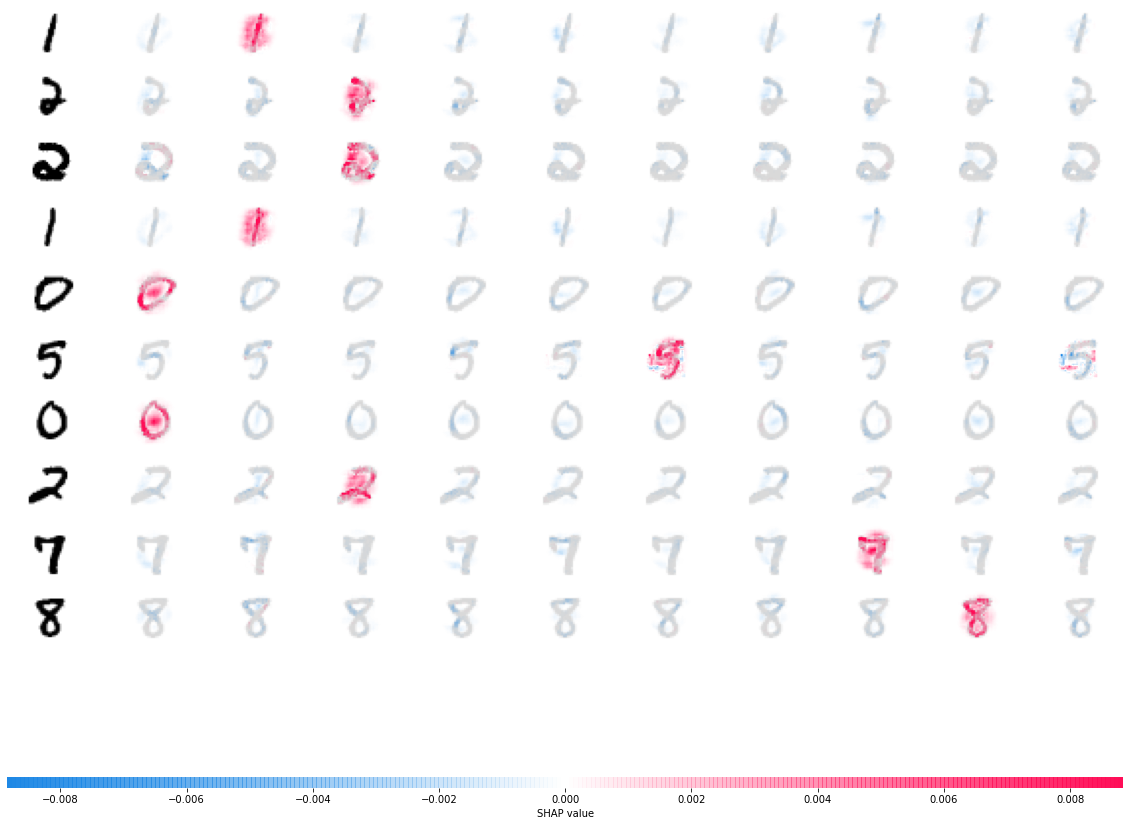

time: 1min (started: 2021-07-16 13:35:03 +00:00)


In [ ]:
samples = x_test[np.random.choice(x_test.shape[0], 10, replace=False)]
shap_values = e.shap_values(samples)
# plot the feature attributions
shap.image_plot(shap_values, -samples)

`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.


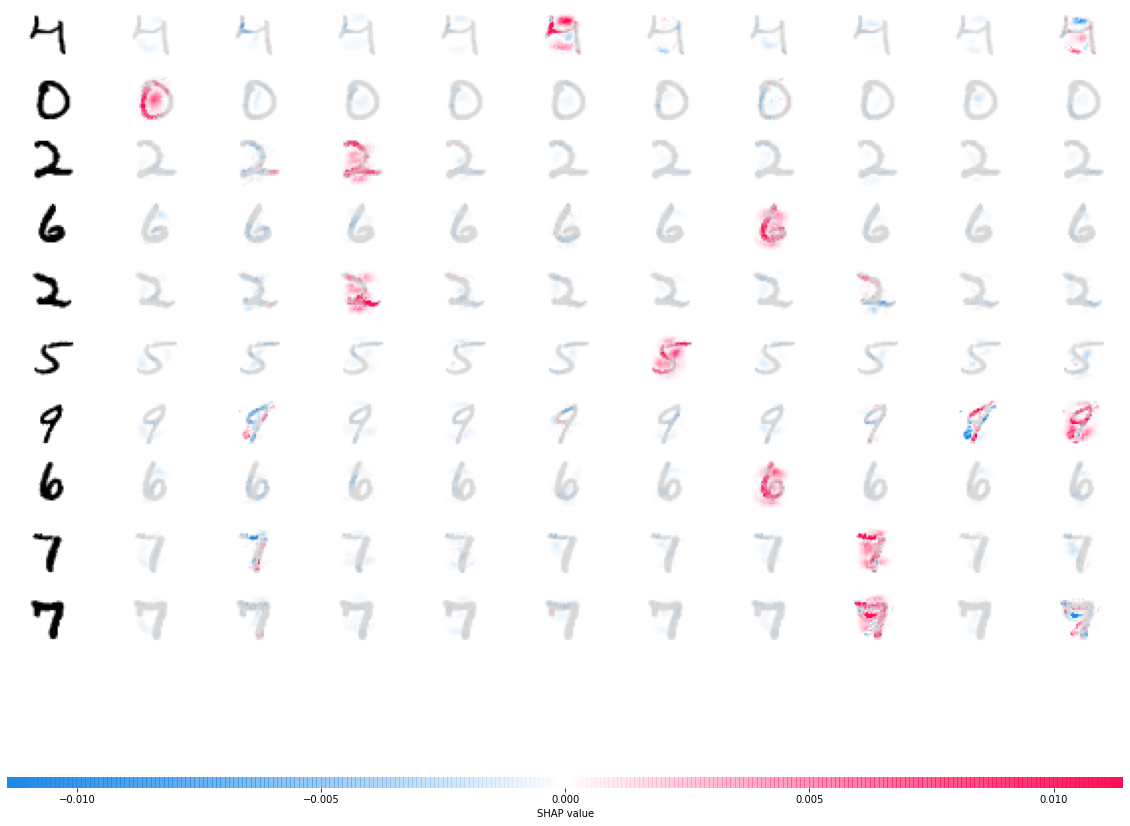

time: 1min 1s (started: 2021-07-15 15:29:44 +00:00)


In [ ]:
samples = x_test[np.random.choice(x_test.shape[0], 10, replace=False)]
shap_values = e.shap_values(samples)
# plot the feature attributions
shap.image_plot(shap_values, -samples)

part5

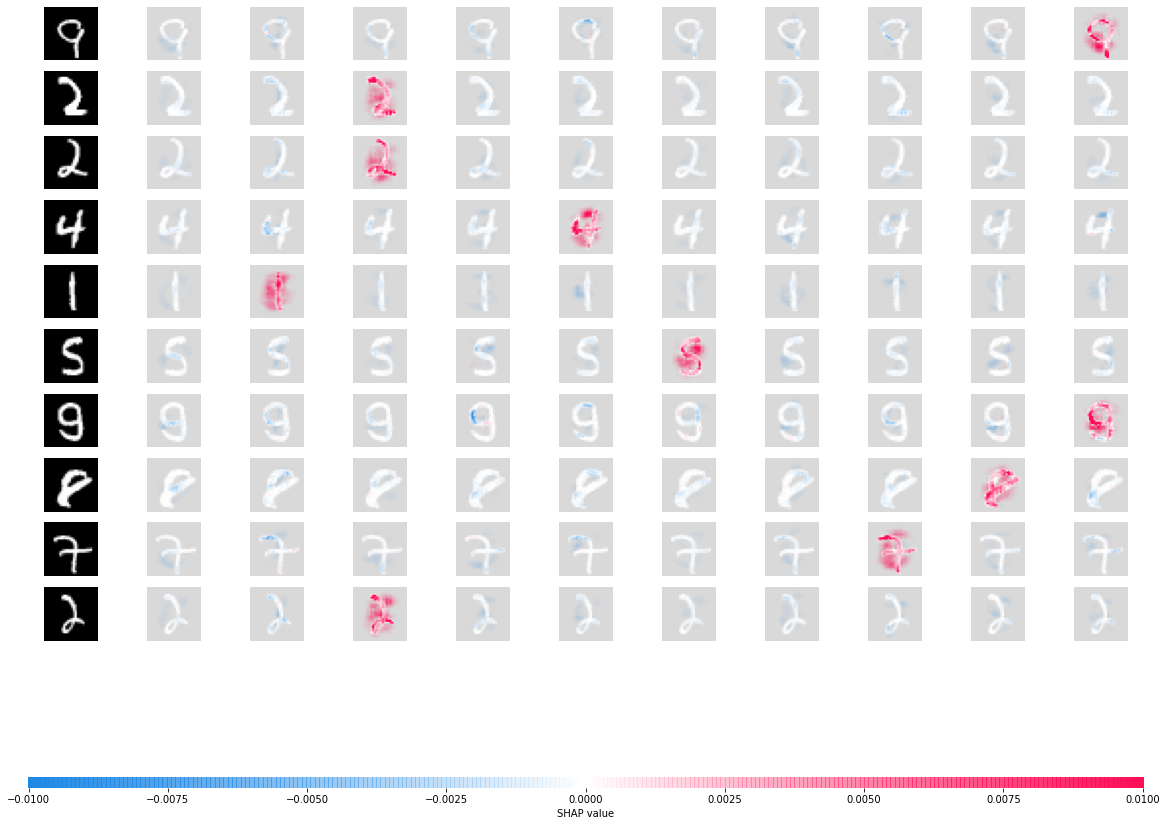

time: 37.9 s (started: 2021-07-16 13:36:31 +00:00)


In [ ]:
samples = x_test[235:245]
shap_values = e.shap_values(samples)
shap.image_plot(shap_values, samples)

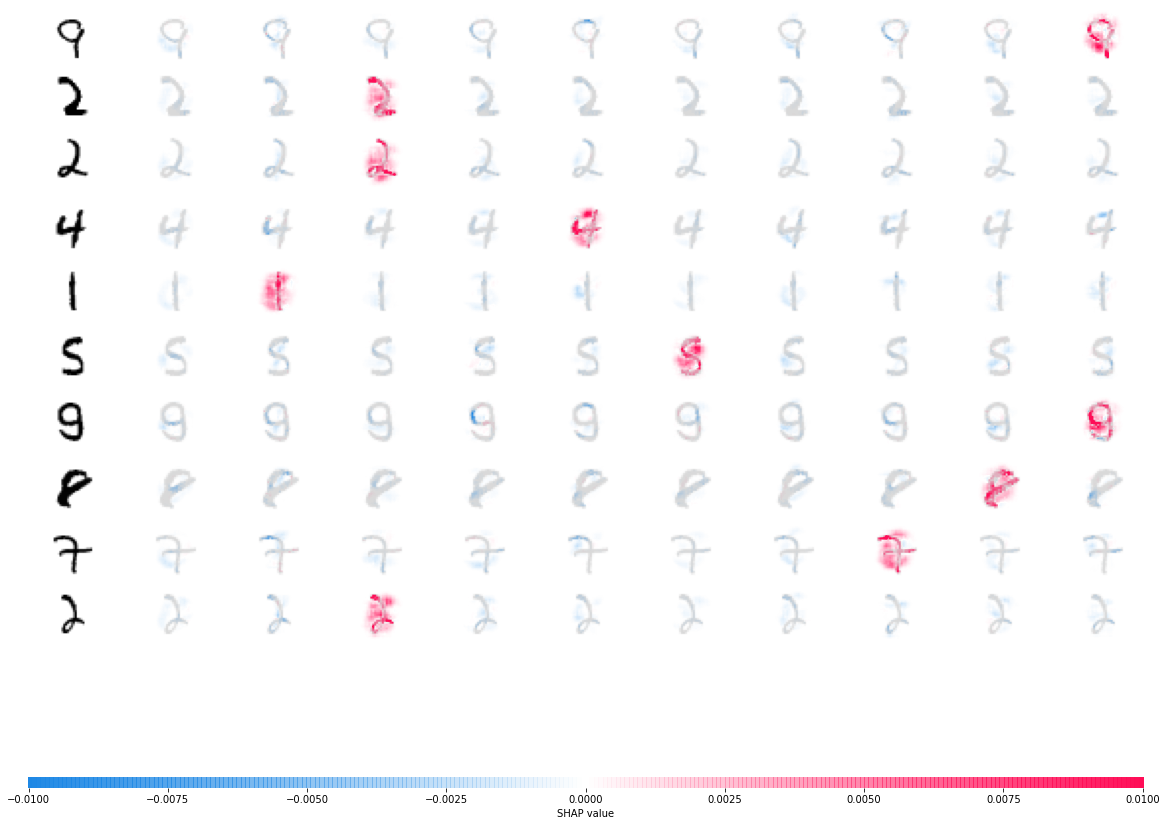

time: 3.52 s (started: 2021-07-16 13:37:09 +00:00)


In [ ]:
shap.image_plot(shap_values, -samples)

In [ ]:
score = mnist_model.evaluate(x_test[235:245], y_test[235:245], verbose = 0) 

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.0009918714640662074
Test accuracy: 1.0
time: 364 ms (started: 2021-07-16 13:37:22 +00:00)


In [ ]:
import math
from random import randrange
tmp_images = samples.copy()


for tmp in range (0,10):
  l = []
  avg=0.0
  for j in range(0,28):
    for k in range(0,28):
      # print("["+str(j)+" "+str(k)+"]"+str(tmp_images[tmp,j,k,0]))
      avg=avg+tmp_images[tmp,j,k,0]
      l.append(-shap_values[tmp][0][j][k][0])
  avg=avg/784
  index=np.argsort(l)
  # print(str(tmp)+":")
  for i in range(0,156):
    posx=math.floor(index[i]/28)
    posy=index[i]%28
    # print("["+str(posx)+","+str(posy)+"]:"+str(shap_values[tmp][0][posx][posy][0])+"    "+str(tmp_images[tmp,posx,posy,0]))
    tmp_images[tmp,posx,posy,0]=avg


new_test_images = np.array(tmp_images)

time: 28.5 ms (started: 2021-07-16 13:37:28 +00:00)


In [ ]:
score = mnist_model.evaluate(x_test[235:245], y_test[235:245], verbose = 0) 

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.0009918714640662074
Test accuracy: 1.0
time: 51.1 ms (started: 2021-07-16 13:37:31 +00:00)


In [ ]:
score = mnist_model.evaluate(new_test_images, y_test[235:245], verbose = 0) 

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.361930251121521
Test accuracy: 0.699999988079071
time: 49.5 ms (started: 2021-07-16 13:37:35 +00:00)


In [ ]:
score = mnist_model.evaluate(new2_test_images, y_test[235:245], verbose = 0) 

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 1722.4732666015625
Test accuracy: 0.10000000149011612
time: 61.6 ms (started: 2021-07-15 20:18:04 +00:00)


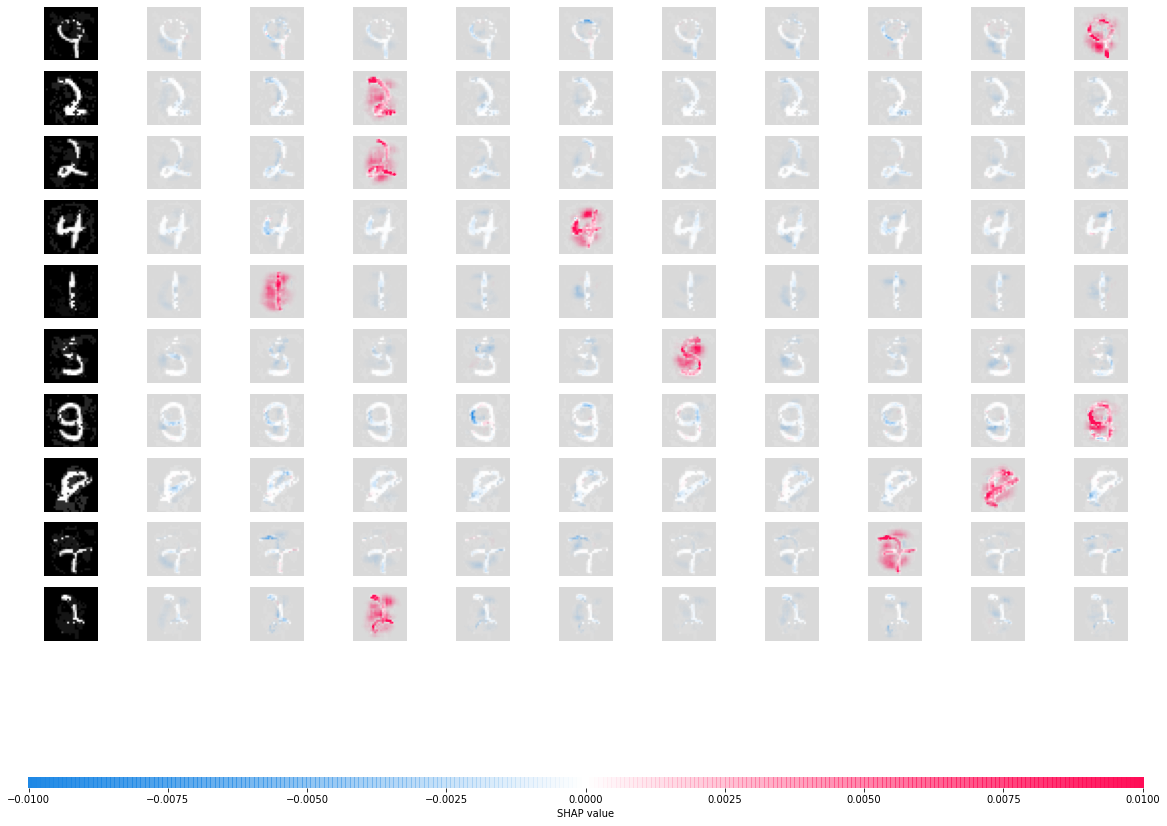

time: 3.37 s (started: 2021-07-16 13:37:49 +00:00)


In [ ]:
shap.image_plot(shap_values, new_test_images)

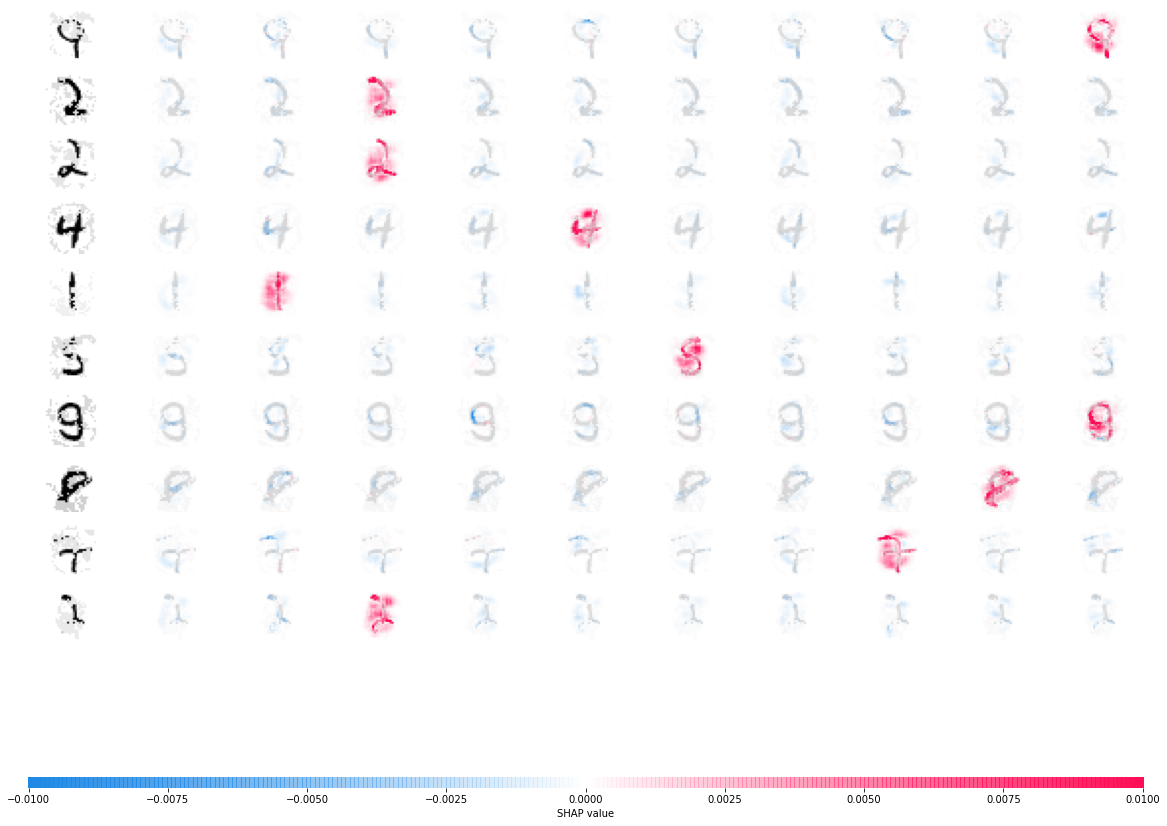

time: 3.41 s (started: 2021-07-16 13:38:02 +00:00)


In [ ]:
shap.image_plot(shap_values, -new_test_images)

In [ ]:
samples = x_test[235:245]
shap_values = e.shap_values(samples)

`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.


time: 1min 35s (started: 2021-07-16 08:36:22 +00:00)


In [ ]:
np.argmax(tmp_y[tmp])
tmp_y[1]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

time: 5.74 ms (started: 2021-07-15 22:12:25 +00:00)


In [ ]:
np.max([1,3,4,7,2])

7

time: 5.24 ms (started: 2021-07-16 08:38:34 +00:00)


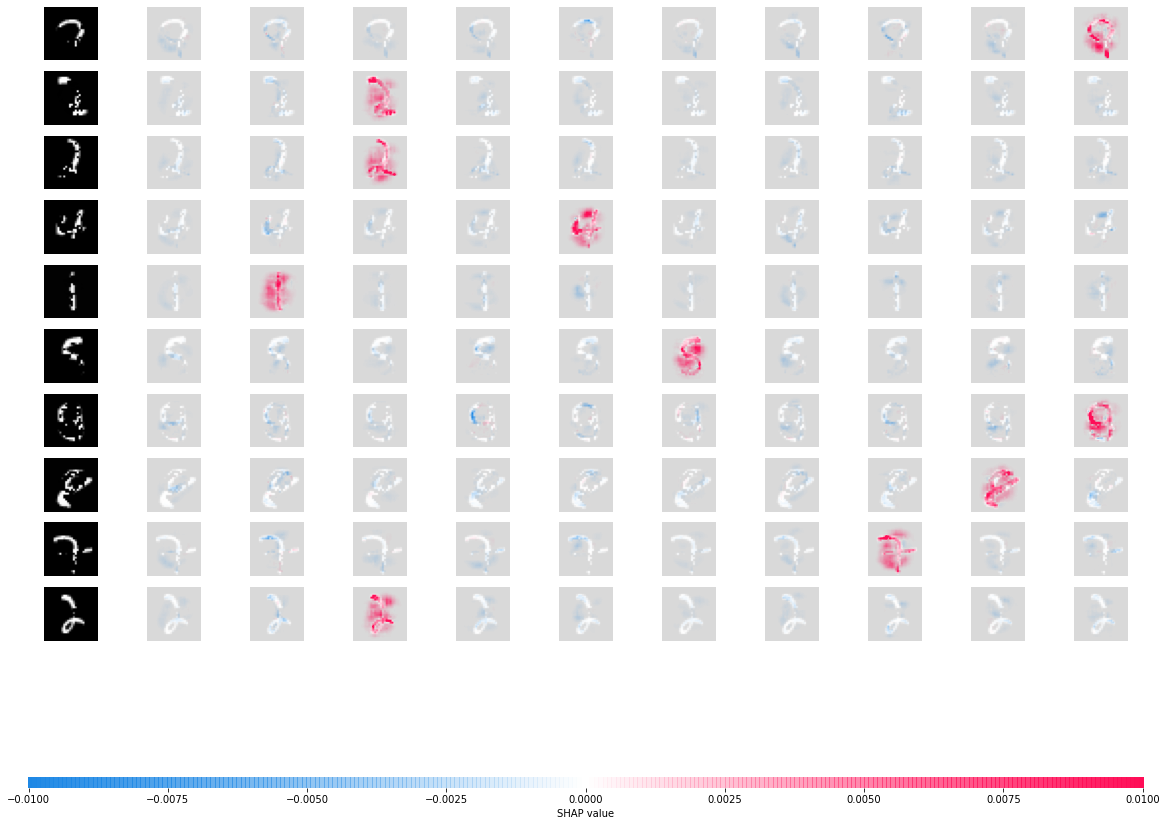

time: 3.4 s (started: 2021-07-16 13:40:57 +00:00)


In [ ]:
import math
import random 
tmp_y = y_test[235:245].copy()
tmp_images = samples.copy()


for tmp in range (0,10):
  l = []
  avg=0.0
  for j in range(0,28):
    for k in range(0,28):
      # print("["+str(j)+" "+str(k)+"]"+str(tmp_images[tmp,j,k,0]))
      avg=avg+tmp_images[tmp,j,k,0]
      # l.append(shap_values[tmp][np.argmax(tmp_y[tmp])][j][k][0])
      l.append(shap_values[tmp][0][j][k][0])
  avg=avg/784
  index=np.argsort(l)
  # print(str(tmp)+":")

  for i in range(0,156):
    posx=math.floor(index[i]/28)
    posy=index[i]%28
    # print("["+str(posx)+","+str(posy)+"]:"+str(shap_values[tmp][0][posx][posy][0])+"    "+str(tmp_images[tmp,posx,posy,0]))
    tmp_images[tmp,posx,posy,0]=l[index[i]]
    # tmp_images[tmp,posx,posy,0]=avg

  # for i in range(157,784):
  #   posx=math.floor(index[i]/28)
  #   posy=index[i]%28
  #   tmp_images[tmp,posx,posy,0]=random.choice([0, 255])

new2_test_images = np.array(tmp_images)
shap.image_plot(shap_values, new2_test_images)

In [ ]:
score = mnist_model.evaluate(new2_test_images, y_test[235:245], verbose = 0) 

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 2.271986484527588
Test accuracy: 0.6000000238418579
time: 51.6 ms (started: 2021-07-16 13:39:21 +00:00)


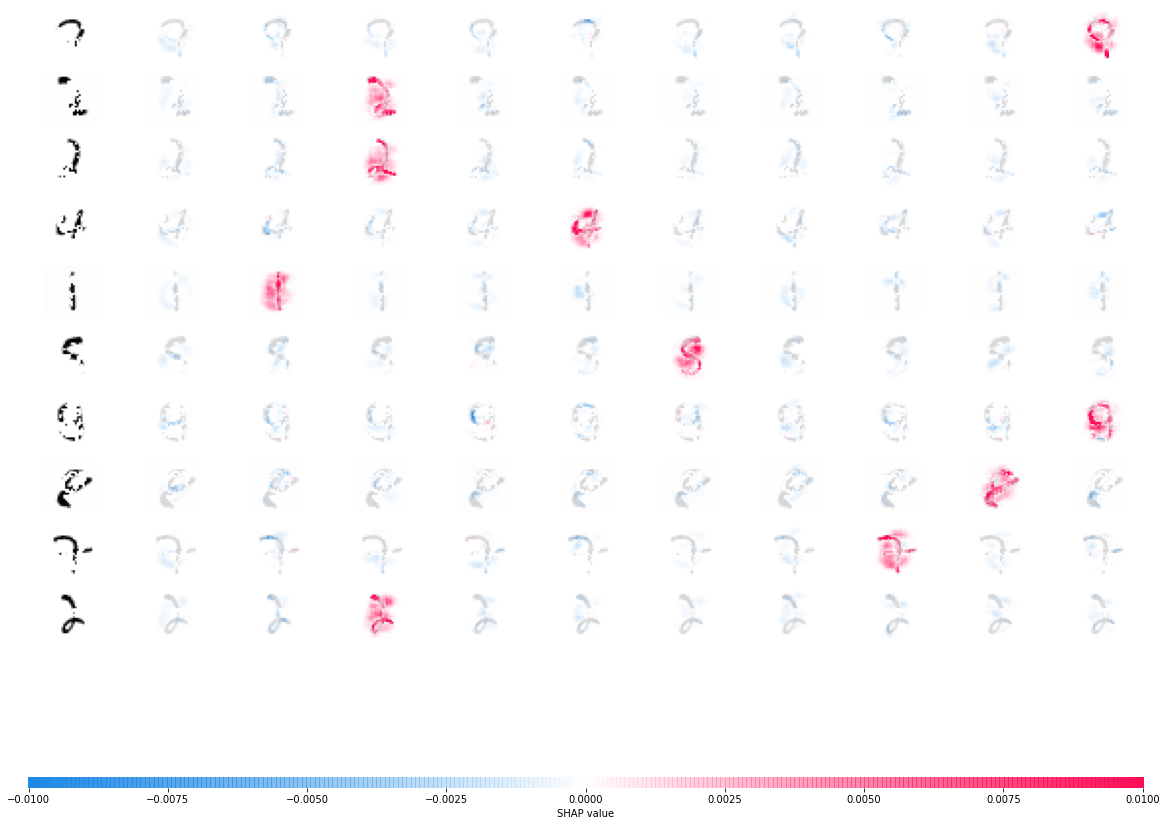

time: 3.26 s (started: 2021-07-16 13:39:12 +00:00)


In [ ]:
shap.image_plot(shap_values, -new2_test_images)

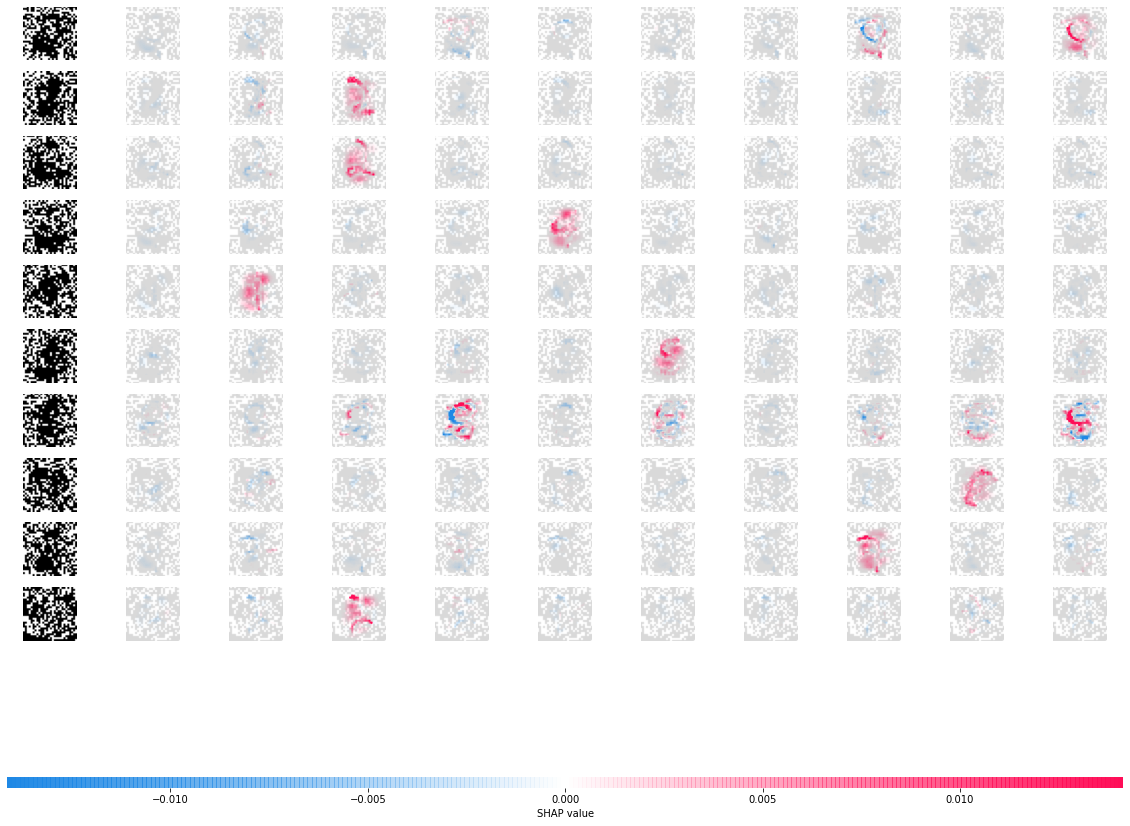

time: 4.42 s (started: 2021-07-16 08:49:09 +00:00)


In [ ]:
import math
import random 
tmp_y = y_test[235:245].copy()
tmp_images = samples.copy()


for tmp in range (0,10):
  l = []
  max = []
  avg=0.0
  for j in range(0,28):
    for k in range(0,28):
      # print("["+str(j)+" "+str(k)+"]"+str(tmp_images[tmp,j,k,0]))
      avg=avg+tmp_images[tmp,j,k,0]
      # l.append(shap_values[tmp][np.argmax(tmp_y[tmp])][j][k][0])
      # for num in range(0,10):
      #   max.append(shap_values[tmp][num][j][k][0])
      l.append(shap_values[tmp][0][j][k][0])
  avg=avg/784
  index=np.argsort(l)
  # print(str(tmp)+":")

  for i in range(0,156):
    posx=math.floor(index[i]/28)
    posy=index[i]%28
    # print("["+str(posx)+","+str(posy)+"]:"+str(shap_values[tmp][0][posx][posy][0])+"    "+str(tmp_images[tmp,posx,posy,0]))
    tmp_images[tmp,posx,posy,0]=l[index[i]]
    # tmp_images[tmp,posx,posy,0]=avg

  for i in range(157,784):
    posx=math.floor(index[i]/28)
    posy=index[i]%28
    tmp_images[tmp,posx,posy,0]=random.choice([0, 255])

new2_test_images = np.array(tmp_images)
shap.image_plot(shap_values, new2_test_images)

#Cifar10

In [ ]:
import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers.convolutional import Convolution2D, ZeroPadding2D
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
from keras.optimizers import SGD
import cv2, numpy as np
from keras.datasets import cifar10
from keras.layers.normalization import BatchNormalization

BATCH_NORM = False

tbCallBack = keras.callbacks.TensorBoard(log_dir='./tensorflow/notrans-BN', histogram_freq=0, 
                            write_graph=True, write_images=False)
batch_size = 128
num_classes = 10
epochs = 40
data_augmentation = True

# The data, shuffled and split between train and test sets:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Convert class vectors to binary class matrices.
y_train = keras.utils.np_utils.to_categorical(y_train, num_classes)
y_test = keras.utils.np_utils.to_categorical(y_test, num_classes)

#model = keras.applications.vgg19.VGG19(include_top=True, weights='imagenet', input_tensor=None, input_shape=None)


x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train[:,:,:,[0,1,2]] = x_train[:,:,:,[2,1,0]] 
x_train[:,:,:,0] -= 103.939
x_train[:,:,:,1] -= 116.779
x_train[:,:,:,2] -= 123.68
x_test[:,:,:,[0,1,2]] = x_test[:,:,:,[2,1,0]] 
x_test[:,:,:,0] -= 103.939
x_test[:,:,:,1] -= 116.779
x_test[:,:,:,2] -= 123.68

datagen = ImageDataGenerator(width_shift_range=0,  # randomly shift images horizontally (fraction of total width)
                             height_shift_range=0,  # randomly shift images vertically (fraction of total height)
                             horizontal_flip=False)

# initiate RMSprop optimizer
opt = keras.optimizers.SGD(lr=0.01, momentum=0.9, decay=0.0001, nesterov=True)

The `lr` argument is deprecated, use `learning_rate` instead.


In [ ]:
# VGG19
model = Sequential()

model.add(Conv2D(64, (3, 3), padding='same', input_shape=(32, 32, 3), name='block1_conv1'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(Conv2D(64, (3, 3), padding='same', name='block1_conv2'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool'))

model.add(Conv2D(128, (3, 3), padding='same', name='block2_conv1'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(Conv2D(128, (3, 3), padding='same', name='block2_conv2'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))
model.add(MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool'))


model.add(Conv2D(256, (3, 3), padding='same', name='block3_conv1'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(Conv2D(256, (3, 3), padding='same', name='block3_conv2'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(Conv2D(256, (3, 3), padding='same', name='block3_conv3'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(Conv2D(256, (3, 3), padding='same', name='block3_conv4'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool'))

model.add(Conv2D(512, (3, 3), padding='same', name='block4_conv1'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(Conv2D(512, (3, 3), padding='same', name='block4_conv2'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(Conv2D(512, (3, 3), padding='same', name='block4_conv3'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(Conv2D(512, (3, 3), padding='same', name='block4_conv4'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))
model.add(MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool'))

model.add(Conv2D(512, (3, 3), padding='same', name='block5_conv1'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(Conv2D(512, (3, 3), padding='same', name='block5_conv2'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(Conv2D(512, (3, 3), padding='same', name='block5_conv3'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(Conv2D(512, (3, 3), padding='same', name='block5_conv4'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))

model.add(Flatten())

model.add(Dense(4096))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(4096, name='fc2'))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(10))
model.add(BatchNormalization()) if BATCH_NORM else None
model.add(Activation('softmax'))



model.compile(loss='categorical_crossentropy',optimizer=opt,metrics=['accuracy'])
model.fit_generator(datagen.flow(x_train, y_train,batch_size=batch_size),
                        steps_per_epoch=x_train.shape[0] // batch_size+1,
                        epochs=epochs,callbacks=[tbCallBack],
                        validation_data=(x_test, y_test))
# model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test))
# model.save_weights('vgg19_cifar10_retrain_weight_BN.h5')


`Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.


Epoch 1/40
391/391 [==============================] - 48s 104ms/step - loss: 2.1985 - accuracy: 0.1510 - val_loss: 1.8234 - val_accuracy: 0.3168
Epoch 2/40
391/391 [==============================] - 38s 97ms/step - loss: 1.7218 - accuracy: 0.3394 - val_loss: 1.5000 - val_accuracy: 0.4465
Epoch 3/40
391/391 [==============================] - 38s 96ms/step - loss: 1.4175 - accuracy: 0.4692 - val_loss: 1.1290 - val_accuracy: 0.5955
Epoch 4/40
391/391 [==============================] - 36s 93ms/step - loss: 1.1669 - accuracy: 0.5824 - val_loss: 1.0248 - val_accuracy: 0.6372
Epoch 5/40
391/391 [==============================] - 38s 97ms/step - loss: 0.9790 - accuracy: 0.6551 - val_loss: 0.8777 - val_accuracy: 0.6921
Epoch 6/40
391/391 [==============================] - 39s 100ms/step - loss: 0.8510 - accuracy: 0.7035 - val_loss: 0.7837 - val_accuracy: 0.7355
Epoch 7/40
391/391 [==============================] - 38s 98ms/step - loss: 0.7615 - accuracy: 0.7417 - val_loss: 0.6848 - val_accurac

time: 25min 39s (started: 2021-07-15 09:01:01 +00:00)


In [ ]:
# from keras.models import model_from_json
# model_json = model.to_json()
# with open("/content/drive/My Drive/shap_cifar10_VGG.json", "w") as json_file:
#     json_file.write(model_json)

# # serialize weights to HDF5
# model.save_weights("/content/drive/My Drive/shap_cifar10_VGG.h5")
# print("Saved model to disk") 

Saved model to disk
time: 4.61 s (started: 2021-07-15 09:59:19 +00:00)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from keras.models import model_from_json
# load json and create model
json_file = open('/content/drive/My Drive/shap_cifar10_VGG.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)
# load weights into new model
loaded_model.load_weights("/content/drive/My Drive/shap_cifar10_VGG.h5")
print("Loaded model from disk")

model = loaded_model
model.compile(loss='categorical_crossentropy',optimizer=opt,metrics=['accuracy'])

Loaded model from disk


In [ ]:
# model.fit_generator(datagen.flow(x_train, y_train,batch_size=batch_size),
#                         steps_per_epoch=x_train.shape[0] // batch_size+1,
#                         epochs=1,callbacks=[tbCallBack],
#                         validation_data=(x_test, y_test))
# model.fit(x_train, y_train, batch_size=batch_size, epochs=1, verbose=1, validation_data=(x_test, y_test))

### shap

In [ ]:
!pip install shap
# output.clear()

     |████████████████████████████████| 358kB 7.3MB/s 
  Created wheel for shap: filename=shap-0.39.0-cp37-cp37m-linux_x86_64.whl size=491630 sha256=dc853f9e654cfac8c2cb23deb0724f72a2b088348657df186e41e662f9b5d4b8
  Stored in directory: /root/.cache/pip/wheels/15/27/f5/a8ab9da52fd159aae6477b5ede6eaaec69fd130fa0fa59f283
Successfully built shap


In [ ]:
import shap
import numpy as np

background = x_train[np.random.choice(x_train.shape[0], 1000, replace=False)]
e = shap.DeepExplainer(model, background)

keras is no longer supported, please use tf.keras instead.
Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode. See PR #1483 for discussion.


`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data

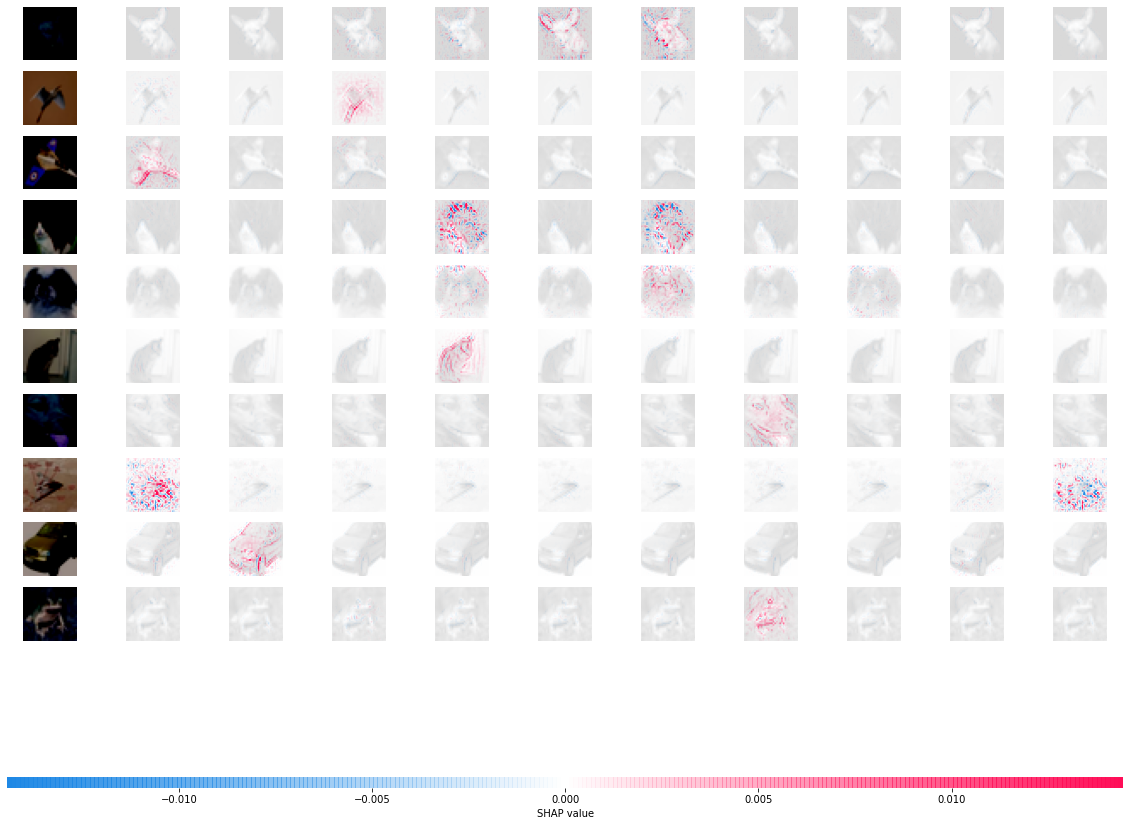

time: 1min 48s (started: 2021-07-15 15:21:44 +00:00)


In [ ]:
samples = x_test[np.random.choice(x_test.shape[0], 10, replace=False)]
shap_values = e.shap_values(samples)
# shap_values = e.shap_values(x_test[1:10])
# plot the feature attributions
labels=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
shap.image_plot(shap_values, samples)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

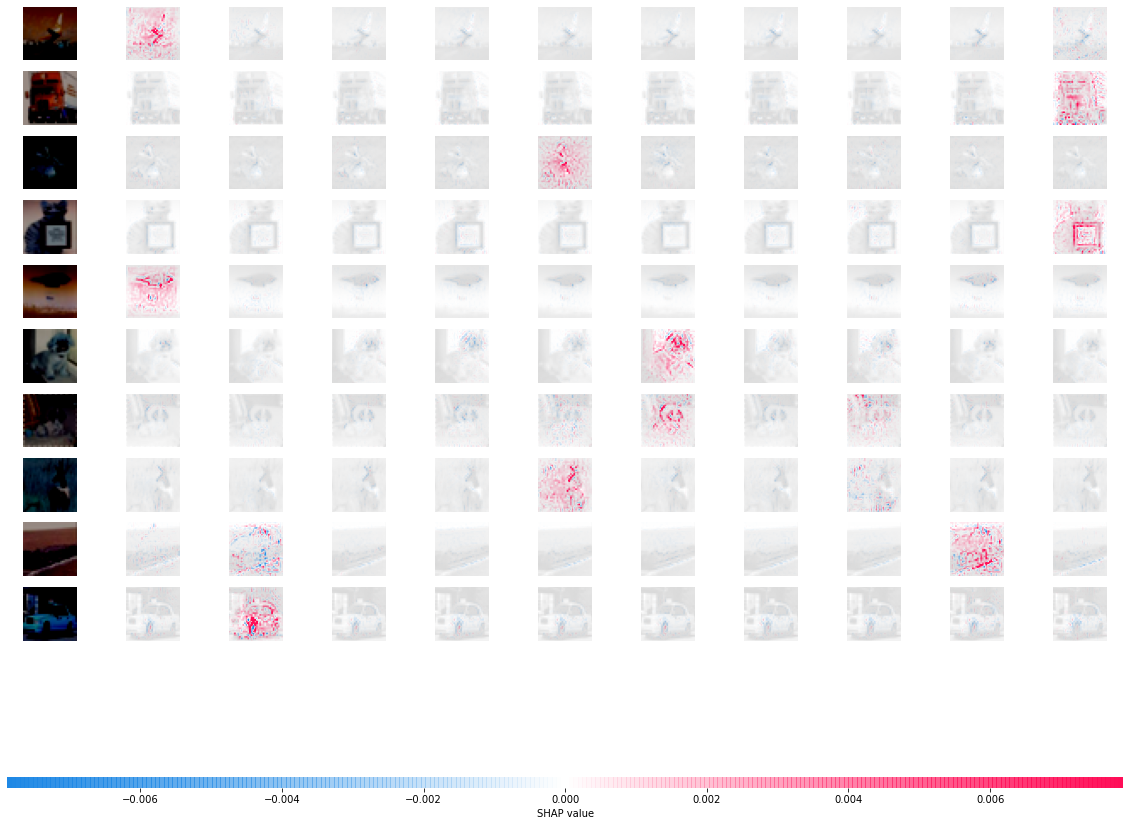

time: 1min 25s (started: 2021-07-15 15:24:50 +00:00)


In [ ]:
samples = x_test[np.random.choice(x_test.shape[0], 10, replace=False)]
shap_values = e.shap_values(samples)
# shap_values = e.shap_values(x_test[1:10])
# plot the feature attributions
labels=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
shap.image_plot(shap_values, samples)

`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data

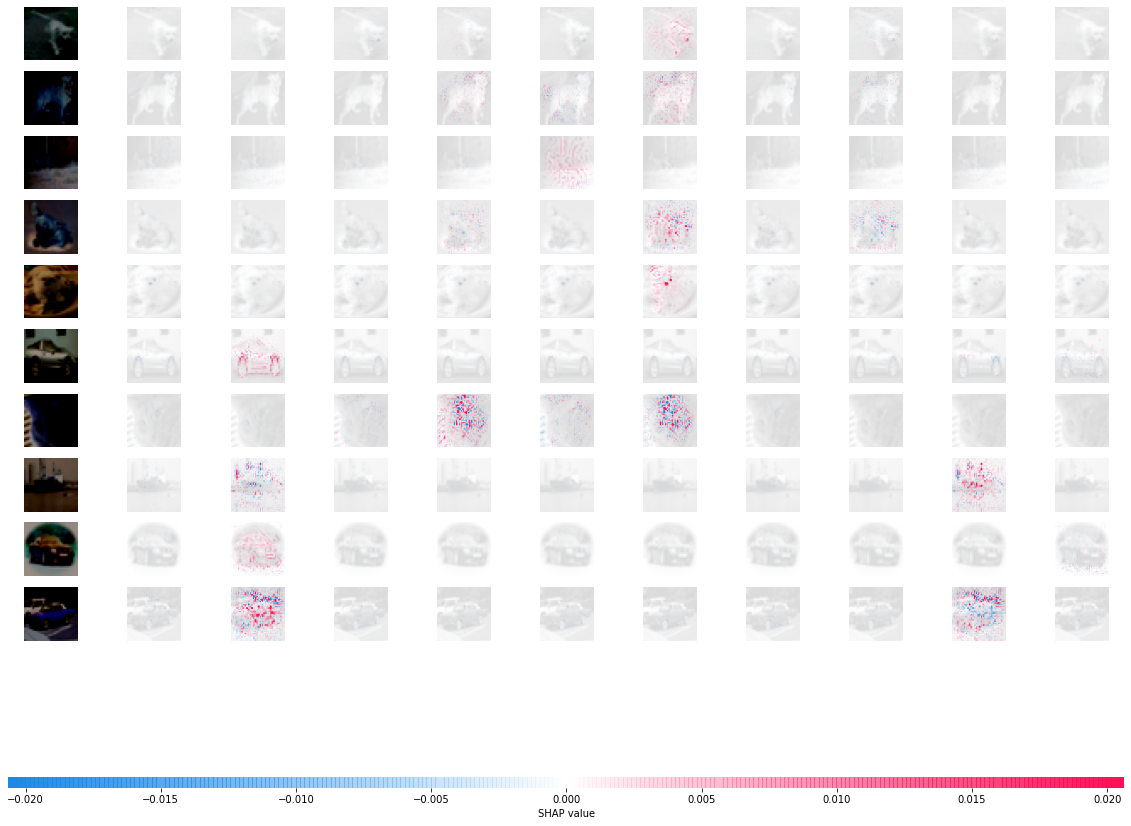

time: 2min 8s (started: 2021-07-15 20:24:43 +00:00)


In [ ]:
samples = x_test[np.random.choice(x_test.shape[0], 10, replace=False)]
shap_values = e.shap_values(samples)
# shap_values = e.shap_values(x_test[1:10])
# plot the feature attributions
labels=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
shap.image_plot(shap_values, samples)

part5

In [ ]:
samples = x_test[279:289]
shap_values = e.shap_values(samples)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

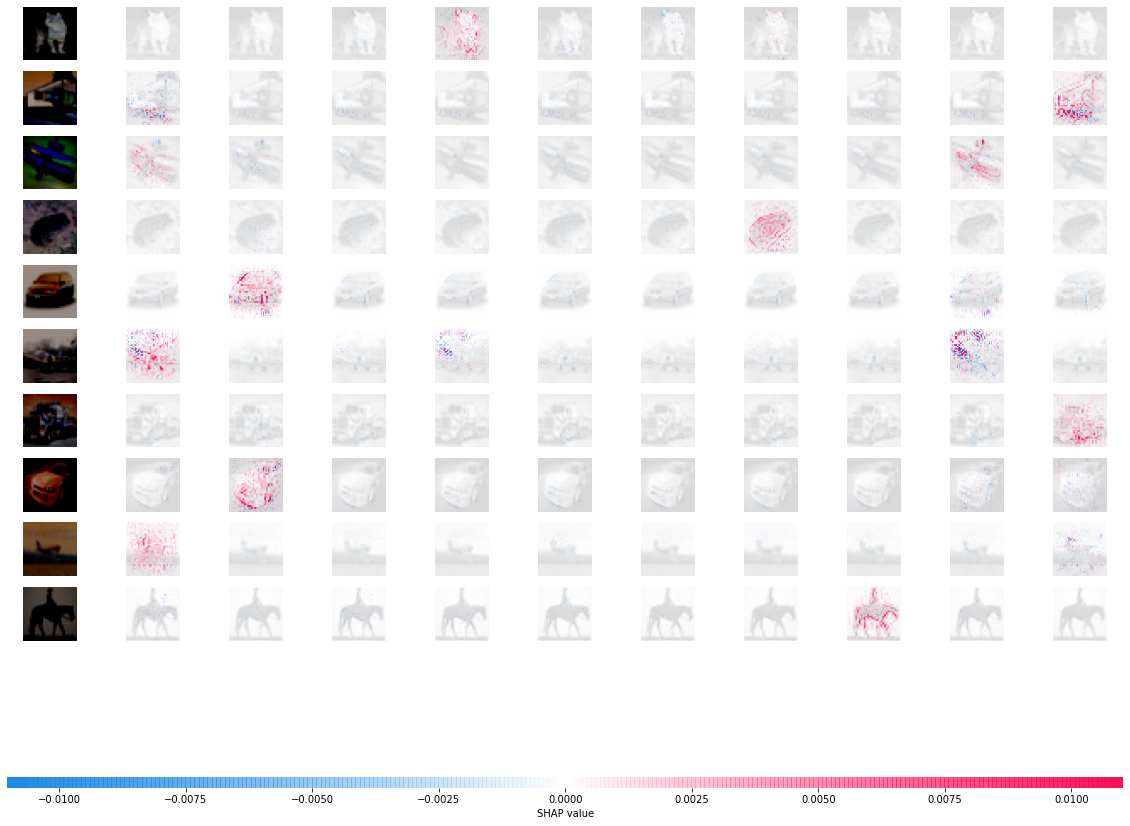

In [ ]:
shap.image_plot(shap_values, samples)

In [ ]:
a = np.zeros(shape=(10,32,32,3))
a

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

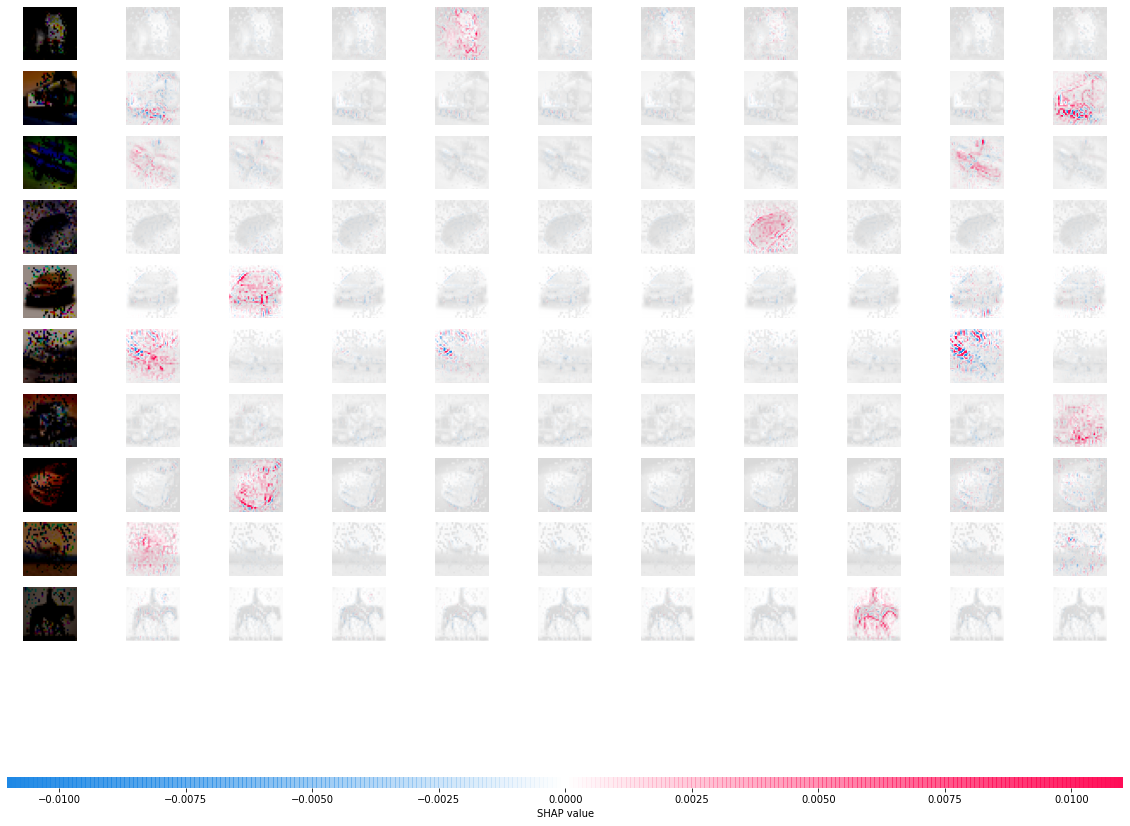

In [ ]:
import math
import random 
tmp_images = samples.copy()
# new_image = np.zeros(shape=(10,32,32,3))
changed = []
for rgb in range(0,3):
  for tmp in range (0,10):
    l = []
    avg=0.0
    for j in range(0,32):
      for k in range(0,32):
        # print("["+str(j)+" "+str(k)+"]"+str(tmp_images[tmp,j,k,0]))
        # avg=avg+tmp_images[tmp,j,k,rgb]
        l.append(shap_values[tmp][0][j][k][rgb])
    avg=avg/len(l)
    index=np.argsort(l)

    for i in range(0,int(0.2*len(l))):
      posx=math.floor(index[i]/32)
      posy=index[i]%32
      # print("["+str(posx)+","+str(posy)+"]:"+str(shap_values[tmp][0][posx][posy][0])+"    "+str(tmp_images[tmp,posx,posy,0]))
      tmp_images[tmp,posx,posy,rgb]=l[index[i]]
      # changed.append([tmp,posx,posy,rgb])
      # tmp_images[tmp,posx,posy,0]=avg


    for i in range(int(0.2*len(l))+1,len(l)):
      posx=math.floor(index[i]/32)
      posy=index[i]%32
      # rand = random.choice([0, 255])
      # tmp_images[tmp,posx,posy,rgb]=rand


new_cifar_test_images = np.array(tmp_images)
shap.image_plot(shap_values, new_cifar_test_images)

In [ ]:
score = model.evaluate(x_test[279:289], y_test[279:289], verbose = 0) 

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.10529638826847076
Test accuracy: 0.8999999761581421


In [ ]:
score = model.evaluate(new_cifar_test_images, y_test[279:289], verbose = 0) 

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 3.186514377593994
Test accuracy: 0.30000001192092896
